1. Modellenmeye Hazır Verinin Yüklenmesi : 
Sadece veriyi yüklemekle kalmıyoruz, hedef değişkenin (Potability) eğitim ve test setindeki dağılımını kontrol ediyoruz.Veriyi böldüğümüzde, içilebilir suların her iki sete de dengeli dağılıp dağılmadığını bilmek modelin adil değerlendirilmesi için şarttır.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, confusion_matrix, classification_report
# İşlenmiş verileri ../data klasöründen çağırıyoruz
X_train = pd.read_csv("../data/data_X_train.csv")
X_test = pd.read_csv("../data/data_X_test.csv")
y_train = pd.read_csv("../data/data_y_train.csv")
y_test = pd.read_csv("../data/data_y_test.csv")

print(f"Eğitim seti: {X_train.shape}, Test seti: {X_test.shape}")

Eğitim seti: (2620, 9), Test seti: (656, 9)


2. Çoklu Model Eğitimi (Decision Tree & Random Forest) :
İki modeli de aynı anda eğiteceğiz ancak performanslarını kıyaslamak için bir döngü ve liste yapısı kullanacağız. Mühendislikte farklı yaklaşımları birbiriyle yarıştırmak esastır. Decision Tree (Karar Ağacı) şeffaftır ama yanılmaya müsaittir; Random Forest ise daha karmaşıktır ama genellikle daha doğru sonuç verir.

In [6]:
# Modellerimizi tanımlıyoruz
# DTC'de max_depth=3 vererek ağacın çok karmaşıklaşıp 'ezberleme' (overfitting) yapmasını engelliyoruz.
models = [
    ("Decision Tree", DecisionTreeClassifier(max_depth=3, random_state=42)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42))
]

final_results = []
confusion_matrices = []

for name, model in models:
    # 1. Eğitim (Training)
    model.fit(X_train, y_train.values.ravel())
    
    # 2. Tahmin (Prediction)
    y_pred = model.predict(X_test)
    
    # 3. Metrik Hesaplama (Precision Score odaklı)
    # Su analizinde 'precision' kritiktir; içilebilir dediğimiz suyun gerçekten içilebilir olması gerekir.
    score = precision_score(y_test, y_pred)
    final_results.append((name, score))
    
    # 4. Karmaşıklık Matrisi
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append((name, cm))

print("Model Karşılaştırma Sonuçları (Precision):", final_results)

Model Karşılaştırma Sonuçları (Precision): [('Decision Tree', 0.5384615384615384), ('Random Forest', 0.609271523178808)]


3. Karmaşıklık Matrisi ve Hata Analizi : 
Sadece sayıları basmak yerine, iki modelin hatalarını yan yana görselleştireceğiz.

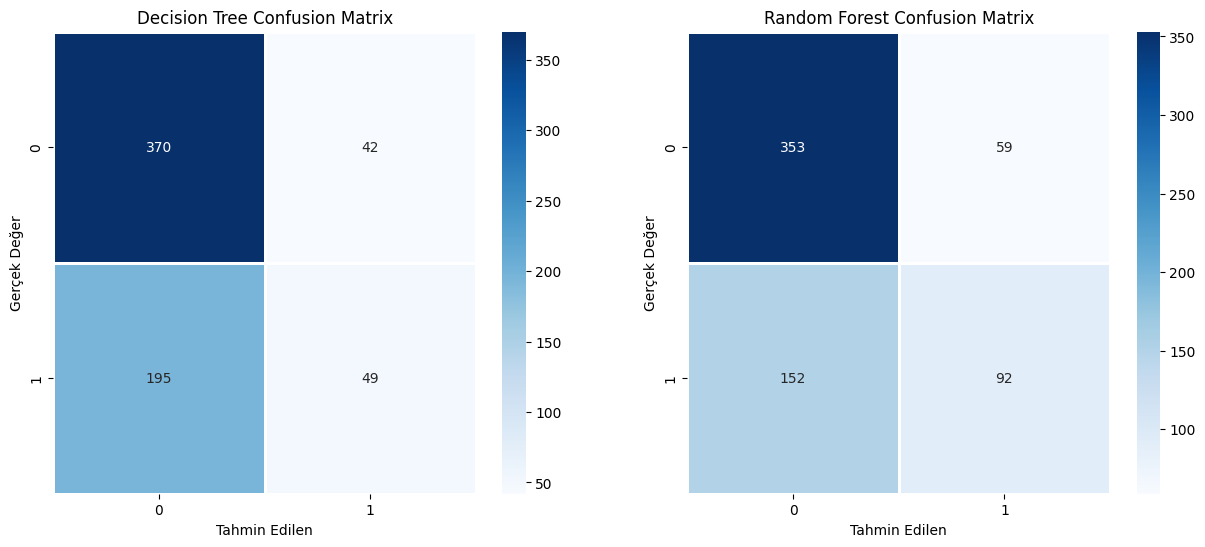

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for i, (name, cm) in enumerate(confusion_matrices):
    sns.heatmap(cm, annot=True, fmt=".0f", linewidths=0.8, cmap='Blues', ax=ax[i])
    ax[i].set_title(f"{name} Confusion Matrix")
    ax[i].set_xlabel("Tahmin Edilen")
    ax[i].set_ylabel("Gerçek Değer")

plt.show()

Yorum : Su içilebilirliği (Potability) gibi insan sağlığı için kritik projelerde Hata Tiplerinin Bedeli (Cost of Error) aynı değildir.Bizim sistemimiz için en tehlikeli hata False Positive durumudur.Zehirli veya uygun olmayan bir suyu insanlara "içilebilir" diye raporlamış oluruz. Su analizinde False Positive'i minimumda tutmak isteriz. Bu yüzden başarı metriği seçerken Precision (Hassasiyet) metriği bizim için çok önemlidir. Precision, "Ben içilebilir diyorsam, o su kesin içilebilirdir" deme güvenidir.False Negative durumunda ise temiz bir suyu israf etmiş veya fazladan arıtma tesisine göndermiş oluruz. Operasyonel maliyet yaratır ama insan zehirlemekten (False Positive) çok daha kabul edilebilir bir hatadır.

4. Karar Ağacının Görselleştirilmesi : 
Yapay zekanın nasıl karar verdiğini görmek için Decision Tree modelini görselleştiriyoruz.Bu ağaç, modelin ilk hangi parametreye baktığını (örn: Sülfat mı yoksa pH mı?) bize söyler.

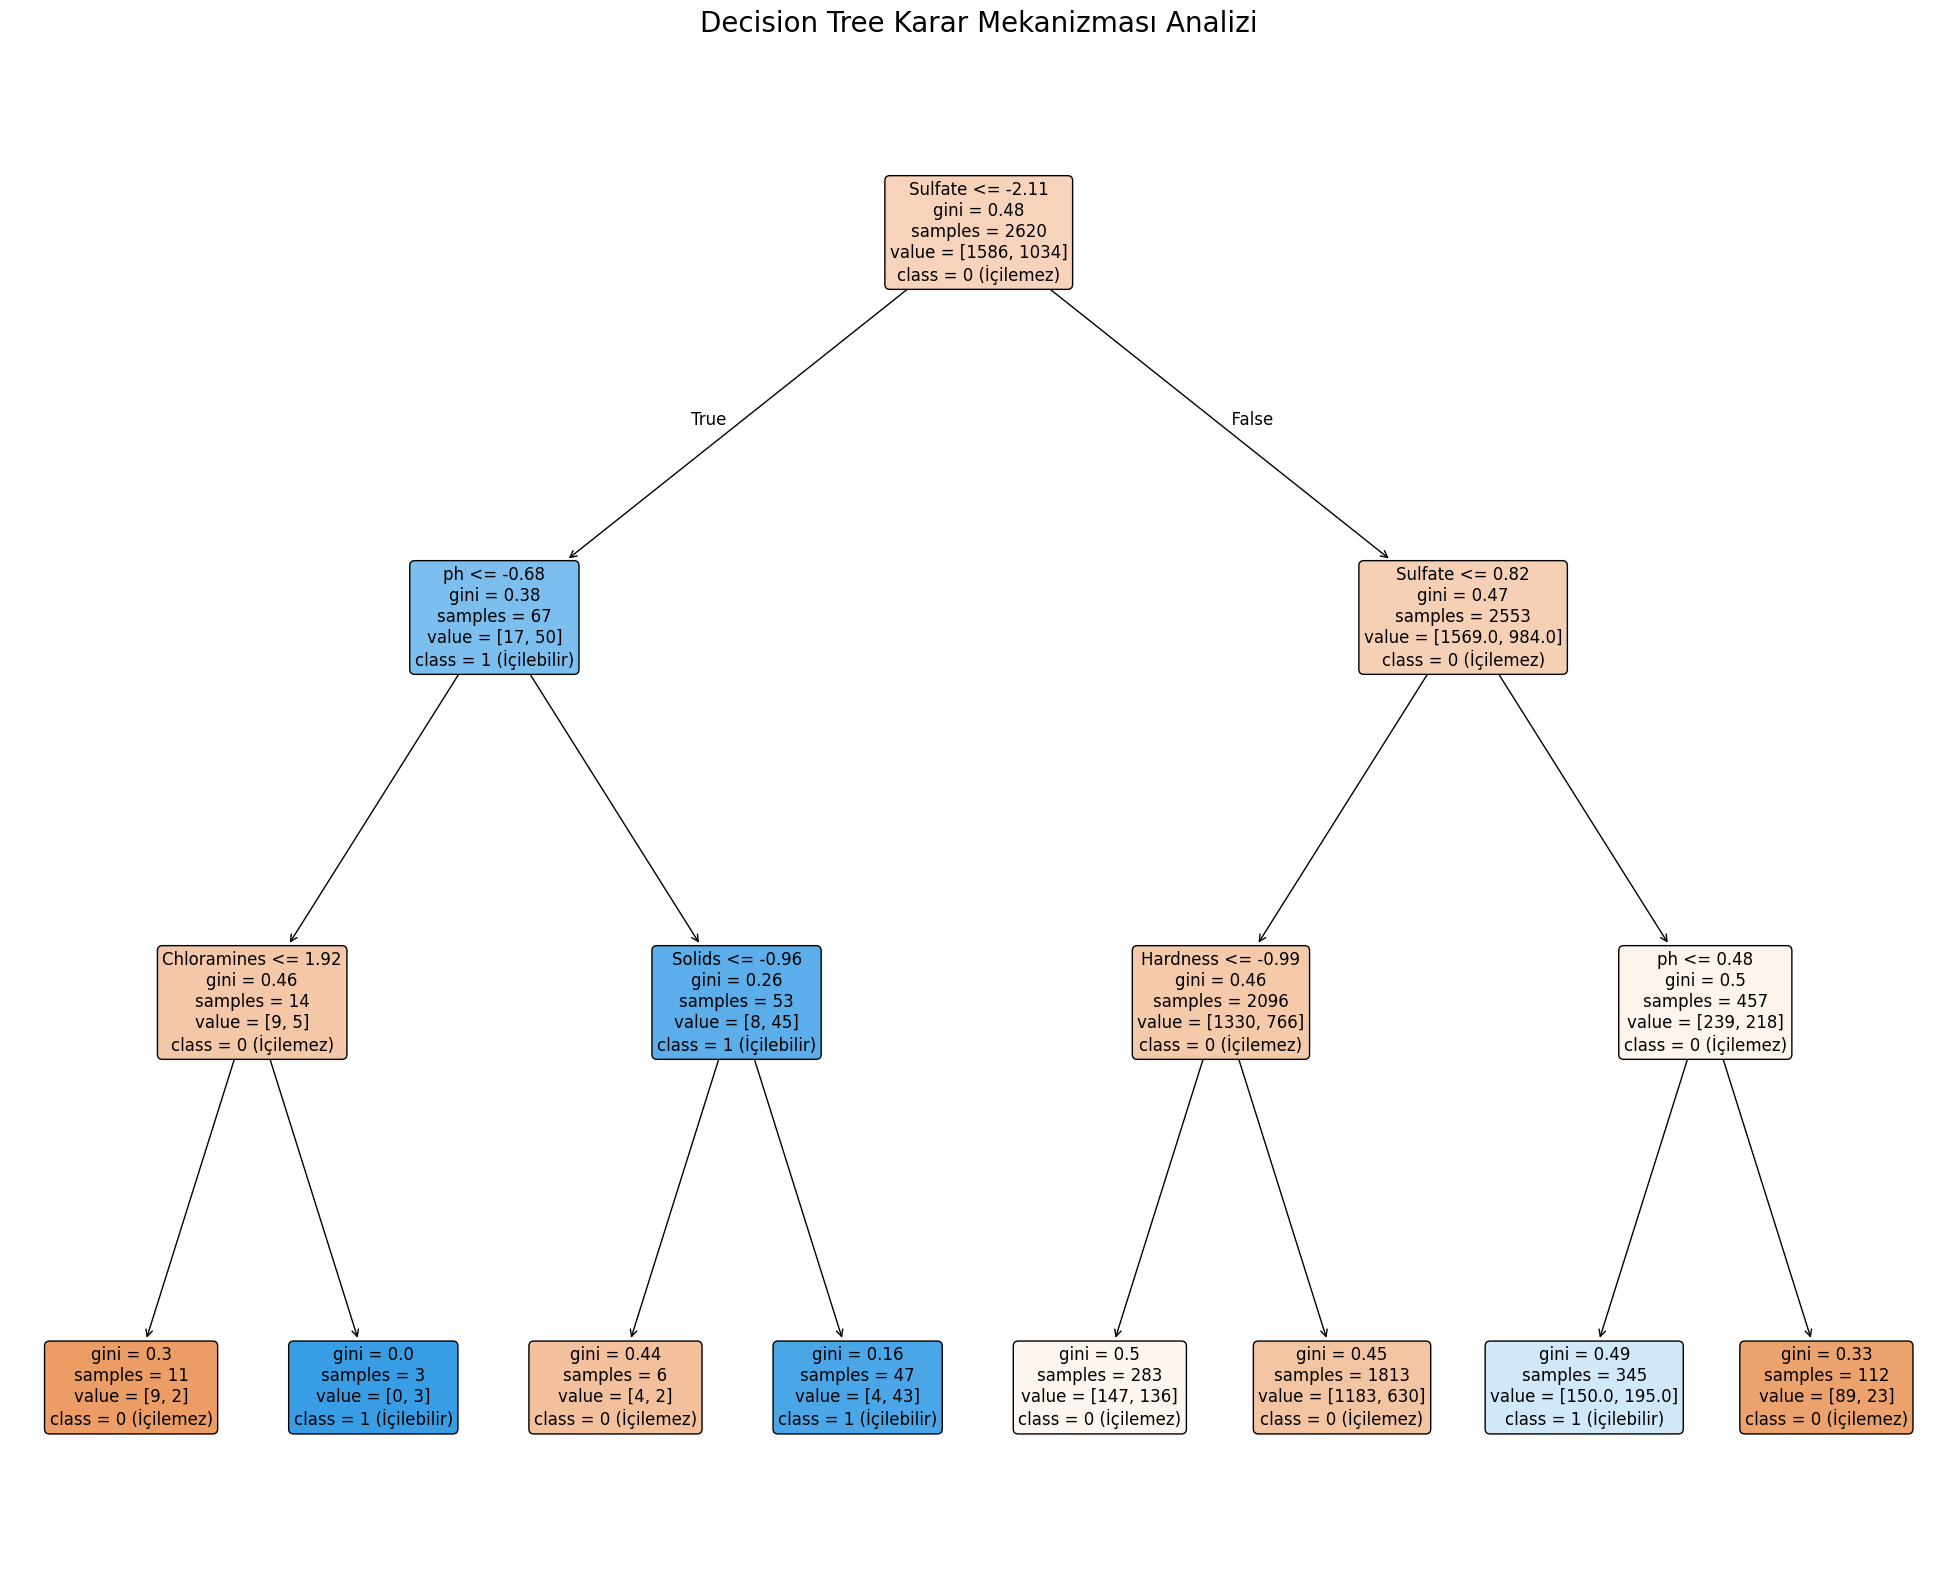

In [8]:
plt.figure(figsize=(25, 20))
dt_clf = models[0][1] # Decision Tree modelini listeden çekiyoruz

plot_tree(dt_clf, 
          feature_names=X_train.columns.tolist(),
          class_names=["0 (İçilemez)", "1 (İçilebilir)"],
          filled=True, 
          precision=2, 
          rounded=True, 
          fontsize=12)

plt.title("Decision Tree Karar Mekanizması Analizi", fontsize=20)
plt.show()

5. Hyperparameter Tuning :
RandomizedSearchCV adımını daha profesyonel bir çapraz doğrulama (RepeatedStratifiedKFold) ile birleştiriyoruz. Modeli sadece eğitmiyoruz, onun için en ideal "ayarları" (parametreleri) otomatik olarak buluyoruz.

Yorum : Karar ağaçlarında max_depth yani max derinlik ormandaki dalların ne kadar uzayacağını belirler.Eğer derinliği sınırlamazsak ve  10-20 gibi çok büyük değerler verirsek model eğitim verisindeki her bir istiisnayı ezberlemeye başlar ve overfitting olur..Derinliği arttırmak modelin karmaşıklığını arttırır ve eğitim verisinde kusursuz çalışşır.Yaklaşık %100 doğruluk verir.Ancak dqaha önce hiç görmediği unseentest  dataseti geldiğinde bocalar ve genelleme yeteneği düşer.Ayrica CPU/GPU bellek tüketimini  ve tahmin süresini arttırır. Biz ağacı 3 seviye ile budayarak (pruning) modeli sade tutmaya zorluyoruz. Amacımız modelin detaylarda boğulmadan sadece en önemli 3 kuralı bulmasını sağlamak (Örneğin: "Önce pH'a bak, sonra Sülfat'a bak gibi"). Bu sayede model gerçek hayattaki unseen test datasetlerindeki verilere daha iyi genelleme yapabilir ve hesaplama maliyeti çok düşük olur.

Yorum : Tek bir Karar Ağacının yanılma payı yüksektir. Random Forest, 100 farklı  Karar Ağacından oluşan bir orman (ensemble) kurar. Her ağaç verinin farklı bir bölgesine bakarak karar verir ve nihai sonuç oylama (majority vote) ile alınır.Sayıyı çok az tutarsak konseyin kararı zayıf kalır. Sayıyı 1000 yaparsak doğruluk bir miktar artabilir ancak model eğitim süresi (Computational Cost) çok uzar. 100, hem performans hem de eğitim süresi açısından optimum bir endüstri standartıdır (Sweet Spot).

In [14]:
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold

# Araştıracağımız parametre aralıkları
model_params = {
    "n_estimators": [10, 50, 100, 200],
    "max_features": ["sqrt", "log2"],
    "max_depth": list(range(1, 21, 3))
}

# Çapraz doğrulama stratejisi: Veriyi 5 parçaya bölüp 2 kez tekrar ederek tarafsız test yapar.
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

rs = RandomizedSearchCV(RandomForestClassifier(), model_params, 
                        cv=cv_strategy, n_iter=10, scoring='precision', random_state=42)

# Not: Hiperparametre tuning'i tüm eğitim verisi (X_train, y_train) ile yapıyoruz
rs.fit(X_train, y_train.values.ravel())

print("--- En İyi Parametreler ---")
print(rs.best_params_)
print(f"\nEn İyi Precision Skoru: {rs.best_score_:.4f}")

C:\Users\sibel\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sibel\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sibel\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

--- En İyi Parametreler ---
{'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': 7}

En İyi Precision Skoru: 0.7125


6. Kaydetme

In [ ]:
import joblib
import os

# Klasör kontrolü
if not os.path.exists("../data"):
    os.makedirs("../data")

# Sadece modelleri kaydediyoruz (Çünkü scaler'ı diğer notebook'ta hallettik)
if 'models' in locals():
    # Decision Tree Kaydı
    joblib.dump(models[0][1], "../data/decision_tree_model.pkl")
    # Random Forest Kaydı
    joblib.dump(models[1][1], "../data/water_potability_model.pkl")
    
    print(" BAŞARILI: Decision Tree ve Random Forest modelleri kaydedildi.")
    print("ℹ NOT: Scaler zaten preprocessing aşamasında kaydedilmişti.")
else:
    print("HATA: Modeller bulunamadı, lütfen eğitim hücresini çalıştırın.")

✅ BAŞARILI: Decision Tree ve Random Forest modelleri kaydedildi.
ℹ️ NOT: Scaler zaten preprocessing aşamasında kaydedilmişti.
